In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor, XGBClassifier, plot_importance
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV, train_test_split

### Deep Dive on Saudi Arabia

#### Set Variables

In [82]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

categorical_cols = ['Driver', 'Team', 'Race', 'TrackStatus', 'Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed', 'Throttle', 'RPM', 'Brake', 'nGear', 'Distance', 'DRS']

sector_times = ['Sector1Time', 'Sector2Time', 'Sector3Time',
              'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime']

scaler = StandardScaler()

In [83]:
# Load clean data
df = pd.read_csv('data/f1_laps_telemetry_saudi_clean.csv')

# Filter out wet tyres
df = df[~((df['Compound']=='INTERMEDIATE') | (df['Compound']=='WET'))]

# Encode and standardize features

# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

#### Use Lap 30 limit

In [84]:
# Limit dataframe to lap number + 5 (predict next 5 laps)
df_copy = df.copy()
df_current = df_copy[df_copy['LapNumber'] <= 30]
df_next_5 = df_copy[(df_copy['LapNumber'] > 30) & (df_copy['LapNumber'] <= 35)]

In [85]:
df_current['LapNumber'].value_counts()

LapNumber
1.0     32881
7.0     29006
16.0    28284
4.0     27377
5.0     27212
14.0    27028
10.0    26705
21.0    26700
13.0    26653
6.0     26651
12.0    26578
22.0    26450
11.0    26414
15.0    26293
23.0    26209
25.0    26198
24.0    26010
26.0    25797
30.0    25382
27.0    25334
29.0    25326
17.0    25068
9.0     25033
28.0    25025
19.0    24566
18.0    21867
20.0    21383
2.0     21032
3.0     20660
8.0     20648
Name: count, dtype: int64

#### Apply encoding and standardization

In [86]:
# Apply cyclical encoding
df_current['WindDir_sin'] = np.sin(np.deg2rad(df_current['WindDirection']))
df_current['WindDir_cos'] = np.cos(np.deg2rad(df_current['WindDirection']))
df_next_5['WindDir_sin'] = np.sin(np.deg2rad(df_next_5['WindDirection']))
df_next_5['WindDir_cos'] = np.cos(np.deg2rad(df_next_5['WindDirection']))

df_current = df_current.drop(columns=['WindDirection'])
df_next_5 = df_next_5.drop(columns=['WindDirection'])

# Label encode
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_current[col] = le.fit_transform(df_current[col].astype(str))
    df_next_5[col] = le.fit_transform(df_next_5[col].astype(str))
    encoders[col] = le

# Convert LapTime to seconds
df_current['LapTimeSeconds'] = pd.to_timedelta(df_current['LapTime']).dt.total_seconds()
df_next_5['LapTimeSeconds'] = pd.to_timedelta(df_next_5['LapTime']).dt.total_seconds()
df_current = df_current.drop(columns=['LapTime'])
df_next_5 = df_next_5.drop(columns=['LapTime'])

# Convert LapTime to seconds for Sectors
for col in sector_times:
    df_current[col] = pd.to_timedelta(df_current[col]).dt.total_seconds()
    df_next_5[col] = pd.to_timedelta(df_next_5[col]).dt.total_seconds()

# Standardize numerical columns
df_current[numerical_cols] = scaler.fit_transform(df_current[numerical_cols])
df_next_5[numerical_cols] = scaler.fit_transform(df_next_5[numerical_cols])

/var/folders/md/k11j6lm14fn29cpdwdfjs85r0000gn/T/ipykernel_91513/253924706.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_current['WindDir_sin'] = np.sin(np.deg2rad(df_current['WindDirection']))
/var/folders/md/k11j6lm14fn29cpdwdfjs85r0000gn/T/ipykernel_91513/253924706.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_current['WindDir_cos'] = np.cos(np.deg2rad(df_current['WindDirection']))
/var/folders/md/k11j6lm14fn29cpdwdfjs85r0000gn/T/ipykernel_91513/253924706.py:4: SettingWithCopyWarning: 


#### Split into train, val, and test sets

In [87]:
# Split into train, val, and test sets
df_current_copy = df_current.copy()
df_next_copy = df_next_5.copy()

# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_current_copy['PitNext5'] = (df_current_copy['LapsTilPit'] <= 5).astype(int)
df_next_copy['PitNext5'] = (df_next_copy['LapsTilPit'] <= 5).astype(int)

# Train, val, test split
train_df_cl = df_current_copy[df_current_copy['Year'].isin([2022, 2023, 2024])]
val_df_cl   = df_next_copy[df_next_copy['Year'] == 2024]
test_df_cl  = df_next_copy[df_next_copy['Year'] == 2025]

# Split sets into features and target
feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Training set
X_train_cl = train_df_cl[feature_cols]
y_train_cl = train_df_cl['PitNext5']

# Validation set
X_val_cl = val_df_cl[feature_cols]
y_val_cl = val_df_cl['PitNext5']

# Test set
X_test_cl = test_df_cl[feature_cols]
y_test_cl = test_df_cl['PitNext5']
X_test_laps_til_pit = test_df_cl['LapsTilPit']

In [88]:
y_train_cl.value_counts()

PitNext5
0    482778
1    102544
Name: count, dtype: int64

In [89]:
# Get shape of train, validation, and test DFs
print(X_train_cl.shape)
print(y_train_cl.shape)
print(X_val_cl.shape)
print(y_val_cl.shape)
print(X_test_cl.shape)
print(y_test_cl.shape)

(585322, 35)
(585322,)
(32029, 35)
(32029,)
(32253, 35)
(32253,)


#### Train XGBoost Classifier model

In [90]:
# Train
xgb_base = XGBClassifier()
xgb_base.fit(X_train_cl, y_train_cl, verbose=0)

# Predict
y_val_pred_cl = xgb_base.predict(X_val_cl)

# Evaluate
print("Initial XGBoost Classifier Validation Set Performance for Saudi Arabia at Lap 30:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

Initial XGBoost Classifier Validation Set Performance for Saudi Arabia at Lap 30:

[[25967   727]
 [ 4603   732]]
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     26694
           1       0.50      0.14      0.22      5335

    accuracy                           0.83     32029
   macro avg       0.68      0.55      0.56     32029
weighted avg       0.79      0.83      0.79     32029



In [91]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train_cl == 0).sum() / (y_train_cl == 1).sum()
ratio

4.708008269620846

#### Fine-tuning XGBoost Classifier model

In [92]:
# Random Search tuning
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, ratio*0.5, ratio]
}

print("Tuning XGBoost Classifier Validation Set Performance for Saudi Arabia at Lap 30:\n")
search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=72,
    scoring='f1',
    cv=3,
    verbose=0,
    random_state=222
)

search.fit(X_train_cl, y_train_cl, verbose=0)

Tuning XGBoost Classifier Validation Set Performance for Saudi Arabia at Lap 30:



,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.1], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,72
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,222
,error_score,nan


#### Evaluate Fine-tuned XGBoost Classifier Model

In [93]:
# Validation Set
best_xgb_cl = search.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print("Results for Tuned XGBoost Classifier Validation Set Performance for Saudi Arabia at Lap 30:\n")
print(search.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

Results for Tuned XGBoost Classifier Validation Set Performance for Saudi Arabia at Lap 30:

{'subsample': 1.0, 'scale_pos_weight': 4.708008269620846, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
[[24879  1815]
 [ 4251  1084]]
              precision    recall  f1-score   support

           0       0.85      0.93      0.89     26694
           1       0.37      0.20      0.26      5335

    accuracy                           0.81     32029
   macro avg       0.61      0.57      0.58     32029
weighted avg       0.77      0.81      0.79     32029



In [94]:
# Test Set
best_xgb_cl = search.best_estimator_
y_test_pred_cl_best = best_xgb_cl.predict(X_test_cl)

print("Results for Tuned XGBoost Classifier Validation Test Performance for Saudi Arabia at Lap 30:\n")
print(search.best_params_)
print(confusion_matrix(y_test_cl, y_test_pred_cl_best))
print(classification_report(y_test_cl, y_test_pred_cl_best))

Results for Tuned XGBoost Classifier Validation Test Performance for Saudi Arabia at Lap 30:

{'subsample': 1.0, 'scale_pos_weight': 4.708008269620846, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
[[25764  1444]
 [ 2156  2889]]
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     27208
           1       0.67      0.57      0.62      5045

    accuracy                           0.89     32253
   macro avg       0.79      0.76      0.78     32253
weighted avg       0.88      0.89      0.88     32253



#### Exploring model results


--- WEIGHT ---


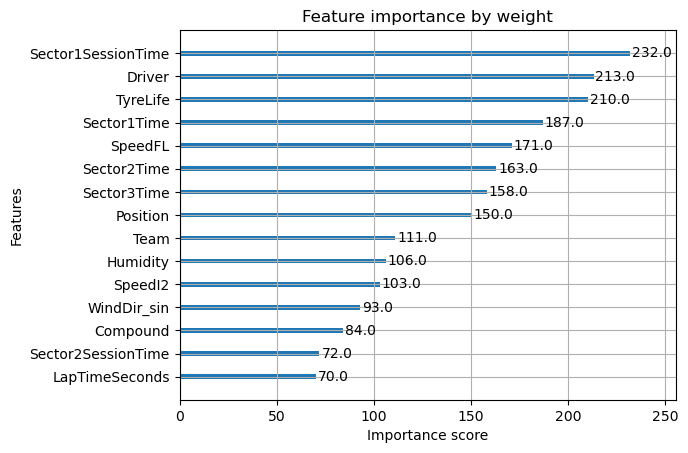


--- GAIN ---


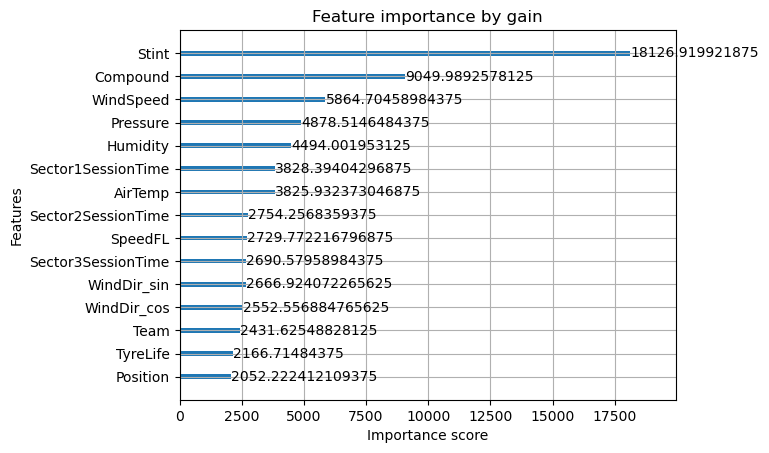


--- COVER ---


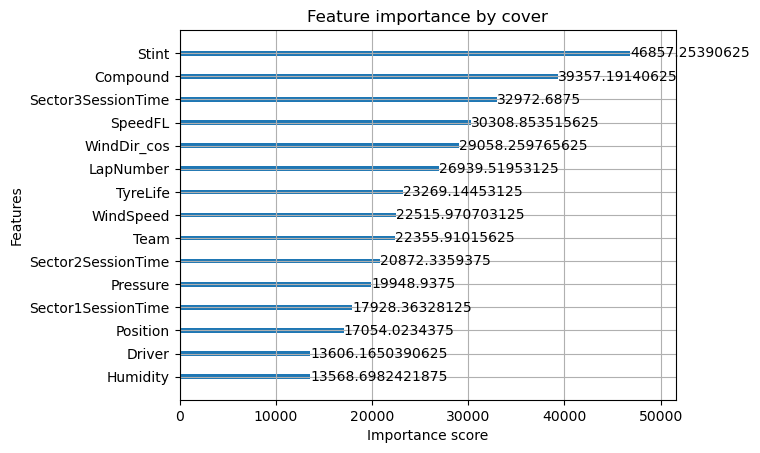

In [95]:
for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_cl, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()

#### Find distribution of False Positive / False Negative laps:

In [96]:
# Add predictions and true labels back to test set
test_results = X_test_cl.copy()
test_results['TrueLabel'] = y_test_cl.values  # true pit/npit
test_results['PredLabel'] = y_test_pred_cl_best
test_results['Correct'] = (test_results['TrueLabel'] == test_results['PredLabel'])

# Reverse categorical encoding
for col in categorical_cols:
    test_results[col] = encoders[col].inverse_transform(test_results[col])

# Reverse standardization
test_results[numerical_cols] = scaler.inverse_transform(test_results[numerical_cols])

# Add LapsTilPit back in
test_results['LapsTilPit'] = X_test_laps_til_pit

In [97]:
# False Positives: Predicted 1 (pit soon), actually 0 (not pitting soon)
false_positives = test_results[(test_results['PredLabel'] == 1) & (test_results['TrueLabel'] == 0)]

# False Negatives: Predicted 0, actually 1
false_negatives = test_results[(test_results['PredLabel'] == 0) & (test_results['TrueLabel'] == 1)]

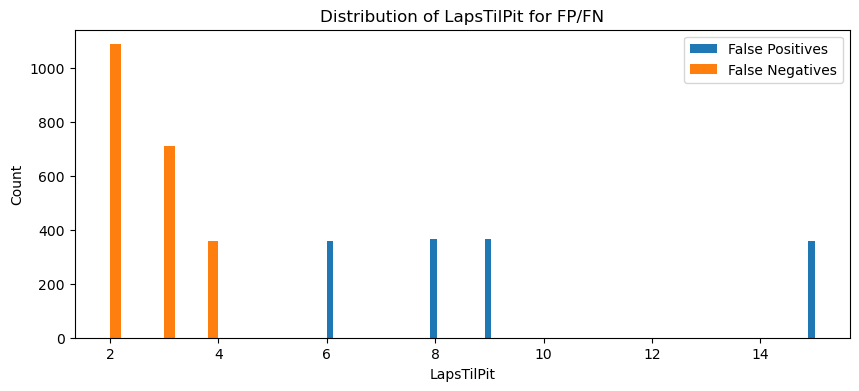

In [98]:
plt.figure(figsize=(10,4))
plt.hist(false_positives['LapsTilPit'], bins=80, label='False Positives')
plt.hist(false_negatives['LapsTilPit'], bins=10, label='False Negatives')
plt.xlabel('LapsTilPit')
plt.ylabel('Count')
plt.legend()
plt.title('Distribution of LapsTilPit for FP/FN')
plt.show()

In [99]:
# Mean TyreLife for FP/FN
print("False Positives: Mean TyreLife", false_positives['TyreLife'].mean())
print("False Negatives: Mean TyreLife", false_negatives['TyreLife'].mean())

False Positives: Mean TyreLife 33.49168975069252
False Negatives: Mean TyreLife 31.503710575139145


In [100]:
print('Stint Precision')
print(test_results.groupby('Stint')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Stint').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Stint').size())

Stint Precision
Stint
1.0    0.499218
2.0    0.971687
3.0    1.000000
Name: Correct, dtype: float64

False Positives
Stint
1.0    1086
2.0     358
dtype: int64

False Negatives
Stint
1.0    1796
2.0     360
dtype: int64


In [101]:
print('Compound Precision')
print(test_results.groupby('Compound')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Compound').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Compound').size())

Compound Precision
Compound
HARD      0.882568
MEDIUM    1.000000
Name: Correct, dtype: float64

False Positives
Compound
HARD    1444
dtype: int64

False Negatives
Compound
HARD    2156
dtype: int64


In [102]:
print('Rainfall Precision')
print(test_results.groupby('Rainfall')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Rainfall').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Rainfall').size())

Rainfall Precision
Rainfall
0    0.888382
Name: Correct, dtype: float64

False Positives
Rainfall
0    1444
dtype: int64

False Negatives
Rainfall
0    2156
dtype: int64


In [103]:
print('TrackStatus Precision')
print(test_results.groupby('TrackStatus')['Correct'].agg(['count', 'mean']))

TrackStatus Precision
             count      mean
TrackStatus                 
1            32253  0.888382


In [104]:
precision_col = 'Rainfall'

print(f'{precision_col} Precision')
print(test_results.groupby(precision_col)['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby(precision_col).size())
print('\nFalse Negatives')
print(false_negatives.groupby(precision_col).size())

Rainfall Precision
Rainfall
0    0.888382
Name: Correct, dtype: float64

False Positives
Rainfall
0    1444
dtype: int64

False Negatives
Rainfall
0    2156
dtype: int64
